**Problem Statement:**

Travelers struggle to efficiently create personalized, cost-effective, and well-organized travel plans due to fragmented information spread across multiple platforms.

In [19]:
import os
from typing import TypedDict, Annotated, List #
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage # Humanmessage from human input # AIMessage is a generated Answer for AI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image


# !pip  install langchain_groq
import langchain_groq
# import uvicorn
# import nest_asyncio
from langchain_groq import ChatGroq

In [20]:
# States.
class PlannerState(TypedDict):
    messages : Annotated[List[HumanMessage | AIMessage], "the message in the conversation"]
    city: str
    interest: List[str]
    itinerary: str

In [21]:
llm = ChatGroq(temperature = 0,
              groq_api_key = "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",
              model_name = "llama-3.3-70b-versatile")

result = llm.invoke("What is Multi AI agent")
result.content


'A Multi-Agent System (MAS) is a system composed of multiple artificial intelligence (AI) agents that interact with each other and their environment to achieve common or individual goals. These agents can be homogeneous (similar) or heterogeneous (different) in terms of their capabilities, goals, and behaviors.\n\nIn a Multi-Agent System, each agent has its own autonomy, making decisions based on its own knowledge, perceptions, and objectives. The agents can communicate with each other, cooperate, or even compete to achieve their goals. The interactions between agents can lead to complex behaviors, emergent properties, and self-organization.\n\nCharacteristics of Multi-Agent Systems:\n\n1. **Autonomy**: Each agent has its own autonomy, making decisions based on its own knowledge and objectives.\n2. **Decentralization**: There is no central controller; each agent operates independently.\n3. **Interactions**: Agents interact with each other and their environment to achieve their goals.\n

In [22]:
itinerary_prompt = ChatPromptTemplate.from_messages([
    ("system","You are helpful assistant. Create a day trip itinerary for {city} based on the user's interests: {interests}. Provide a brief, bulleted itinerary"),
    ("human","Create an itinerary for my day trip"),

])


In [23]:
# Define Agent function.

In [24]:
def input_city(state: PlannerState) -> PlannerState: # It represents a function accepts input argument name state, and that this input must be an object of a custome class or data type called PlannerState.
  print("Please enter the city you want to visit for your day trip:")
  user_message = input("Your Input: ")
  return {
      **state,
      "city": user_message,
      "message": state["messages"] + [HumanMessage(content=user_message)]

  }

def input_interest(state: PlannerState) -> PlannerState:
  print(f"Please enter your interest for the trip to : {state['city']} (comma-seperated)")
  user_message = input("Place of Interest: ")
  return {
      **state,
      "interest": [interest. strip() for interest in user_message.split(",")],
      "messages": state["messages"] + [HumanMessage(content=user_message)]
    }

# timetable created for travel plan.
def create_itinerary(state: PlannerState) -> PlannerState:
  print(f"Creating an itinerary for : {state['city']} based on interest:{", ".join(state['interest'])}"),
  response = llm.invoke(itinerary_prompt.format_messages(city=state["city"], interests=", ".join(state["interest"])))
  print("Final Itinerary: ")
  print(response.content)
  return {
      **state,
      "messages": state["messages"] + [AIMessage(content=response.content)],
      "itinerary": response.content,
    }



### Create and Compile the State Graph

### Display the Graph Structure

In [25]:
workflow  = StateGraph(PlannerState)

workflow.add_node("input_city", input_city)
workflow.add_node("input_interest", input_interest)
workflow.add_node("create_itinerary", create_itinerary)


workflow.set_entry_point("input_city")

workflow.add_edge("input_city", "input_interest")
workflow.add_edge("input_interest", "create_itinerary")
workflow.add_edge("create_itinerary", END)

app = workflow.compile()

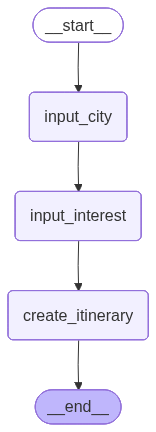

In [26]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method = MermaidDrawMethod.API
        )
    )
    )

Define the function thats run the graph

In [27]:
def travel_planner(user_request: str):
  print(f"Initial Request: {user_request}\n")
  state = {
      "messages": [HumanMessage(content=user_request)],
      "city": "",
      "interest": [],
      "itinerary": "",
  }
  for output in app.stream(state):
    pass

In [28]:
user_request = "Plan my trip"
travel_planner(user_request)

Initial Request: Plan my trip

Please enter the city you want to visit for your day trip:
Your Input: West Bengal
Please enter your interest for the trip to : West Bengal (comma-seperated)
Place of Interest: Darjeeling
Creating an itinerary for : West Bengal based on interest:Darjeeling
Final Itinerary: 
Here's a brief, bulleted itinerary for a day trip to Darjeeling, West Bengal:

* 6:00 AM: Start the day with a scenic drive to Tiger Hill to watch the sunrise over the Himalayas
* 8:00 AM: Visit the Batasia Loop and Ghoom Monastery
* 10:00 AM: Explore the Darjeeling Himalayan Railway (Toy Train) and take a short ride
* 12:00 PM: Have lunch at a local restaurant and try some traditional Nepali and Tibetan cuisine
* 1:30 PM: Visit the Padmaja Naidu Himalayan Zoological Park and the Himalayan Mountaineering Institute
* 4:00 PM: Take a stroll around the Mall Road and do some shopping for local handicrafts and tea
* 6:00 PM: End the day with a beautiful view of the sunset from a viewpoint

